Dataset
----

In [85]:
import warnings
warnings.filterwarnings("ignore")

In [86]:
from torch.utils.tensorboard import SummaryWriter

# Load tensorboard extension for Jupyter Notebook, only need to start TB in the notebook
#%load_ext tensorboard
%reload_ext tensorboard

In [87]:
from sklearn.preprocessing   import OneHotEncoder
from sklearn.datasets        import fetch_20newsgroups
from sklearn.metrics         import classification_report
from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt
import numpy as np

from collections import Counter
from tqdm import tqdm
from math import floor

from nltk.tokenize import sent_tokenize, word_tokenize, RegexpTokenizer

from torch.utils.data import DataLoader, TensorDataset
import torch.nn.functional as F
import torch.nn as nn
import torch
torch.manual_seed(seed = 42)
device = torch.device('cpu') #torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
print(device)

cpu


In [88]:
@torch.no_grad()
def eval_model(model, device, data_loader, target_names = False):
    model.eval()
    all_pred   = torch.empty((0,), dtype = torch.float32).to(device)
    all_labels = torch.empty((0,), dtype = torch.float32).to(device)

    for data_inputs, data_labels in data_loader:
        data_inputs = data_inputs.to(device)
        data_labels = data_labels.to(device)
        preds,_ = model(data_inputs)
        pred_labels = F.one_hot(preds.argmax(dim = 1),num_classes=3)

        all_pred   = torch.cat((all_pred,pred_labels), dim = 0 )
        all_labels = torch.cat((all_labels,data_labels))
    print(classification_report(y_pred =   all_pred.cpu().numpy(), y_true = all_labels.cpu().numpy(),  target_names  = target_names, zero_division = 0))

In [89]:
newsgroups_train = fetch_20newsgroups(data_home = '/home/drew/Split-Learning/Data',
                                      subset    = 'all',
                                      download_if_missing = True,
                                      remove    = ('headers', 'footers', 'quotes'),
                                      categories= ['rec.motorcycles','rec.sport.baseball','sci.space'])

X, Y = newsgroups_train.data, newsgroups_train.target
print(len(X))
print(Y.shape)

2977
(2977,)


We split each "document" based on the amount of words (deliminited by a space) and ensure that each dataeu has the same number of words.

In [90]:
# Filter based on the number of words 
n_words_min = 100 # min([len(document.split()) for document in X]) -> 192 NOT INCLUDING EMPTY DESC

bool_len = lambda doc: True if len(doc.split()) >= n_words_min else False
mask = np.array([bool_len(document) for document in X])
Y = Y[mask]

X = [document for document in X if len(document.split()) >= n_words_min]
Counter(Y)

Counter({2: 431, 1: 381, 0: 319})

---

In [91]:
#from gensim.models import Word2Vec
#import gensim
"""
[nltk_data] Downloading package punkt_tab to /home/drew/nltk_data...
[nltk_data] Package punkt_tab is already up-to-date!
"""
tokenizer = RegexpTokenizer(r'\w+')

In [92]:
#data = [[[ word for word in word_tokenize(sentence)] for sentence in sent_tokenize(sample)] for sample in X]
# Doesn't seem right since we are creating lists of sentences
data  = [tokenizer.tokenize(document) for document in X]
# Get the smallest seq
seq_len = min([len(document) for document in data]);
print(seq_len)
# Truncate each document to the shortest
data    = [document[:seq_len] for document in data]

93


In [93]:
all_words = set([word for sent in data for word in sent])
dc = {s:i for i,s in enumerate(sorted(all_words))}
sorted(list(dc.items()),key = lambda x: x[1])[:10]
print(len(dc.keys()))

13749


In [94]:
number_of_words = max(dc.values())
number_of_words

13748

In [95]:
embed = [[dc[w] for w in document] for document in data]
# Each word is tied to a number range -> [0,13748]
embed[0][:10]

[3517, 2508, 12860, 13501, 5368, 5323, 12814, 12048, 8771, 11984]

In [96]:
X = np.array(embed) 
print(X.shape)

(1131, 93)


----

In [97]:
enc = OneHotEncoder(handle_unknown='ignore', sparse_output = False)
Y = enc.fit_transform(Y.reshape(-1, 1)) # Should be (sampeles, 3)
print(Y.shape)
print(Y[0])

(1131, 3)
[0. 1. 0.]


X and Y are in the proper format for training.
- X instance is [3517, 2508, 12860, 13501, 5368, 5323, 12814, 12048, 8771, 11984] 
- Y instance is [0. 1. 0.]

In [98]:
assert(len(X.shape)) == 2
samples, seq_len = X.shape
#X = X.reshape(samples,seq_len)
X_train, X_test, Y_train, Y_test = train_test_split(X,Y, test_size = 0.2,random_state = 42) 

X_train = torch.from_numpy(X_train).long()
Y_train = torch.from_numpy(Y_train).type(torch.float32)

X_test  = torch.from_numpy(X_test) .long()
Y_test  = torch.from_numpy(Y_test) .type(torch.float32)

training_dataset = TensorDataset(X_train,Y_train)
testing_dataset  = TensorDataset(X_test ,Y_test )

train_loader = DataLoader(TensorDataset(X_train,Y_train) , batch_size = X_train.shape[0], shuffle = False)
test_loader  = DataLoader(TensorDataset(X_test ,Y_test ) , batch_size = X_test.shape[0] , shuffle = False)

In [99]:
def train_model(model,device, optimizer ,data_loader, loss_module, num_epochs=100):
    
    writer = SummaryWriter('/home/drew/Split-Learning/Logs',comment = 'Trial 1')
    model_plotted = False
    model.train()
    train_losses  = []
    for epoch in tqdm(range(num_epochs)):
        epoch_loss = 0.0
        for data_inputs, data_labels in data_loader:
            # Put training data into GPU
            data_inputs = data_inputs.to(device)
            data_labels = data_labels.type(torch.float32).to(device)
            # Log
            if not model_plotted:
                writer.add_graph(model, data_inputs)
                model_plotted = True

            preds, alpha = model(data_inputs)
            preds = preds.type(torch.float32).to(device)
            
            loss  = loss_module(preds, data_labels)
            epoch_loss += loss.item()
            train_losses.append(loss.item())

            # Zero the gradients
            optimizer.zero_grad()
            loss     .backward()
            optimizer.step()
        epoch_loss /= len(data_loader)
        writer.add_scalar('training_loss', epoch_loss, global_step = epoch + 1)
        if (epoch + 1) % 10 == 0:
            ...
            # fig = visualize_classification(model, val_dataset.data, val_dataset.label)
            # writer.add_figure('predictions', fig, global_step = epoch + 1)
    writer.close()

    return train_losses

In [100]:
class Net(nn.Module):
    def __init__(self, label_space, num_of_words, embed_d, num_of_filters, kernel_size):
        super().__init__()
        self.embed = nn.Embedding(num_embeddings = num_of_words ,embedding_dim=embed_d, padding_idx=0)
        self.conv  = nn.Conv1d(embed_d, num_of_filters, kernel_size = kernel_size, padding = int(floor(kernel_size//2)))
        self.U     = nn.Linear(num_of_filters, label_space)
        self.final = nn.Linear(num_of_filters, label_space)
        self.embed_drop = nn.Dropout(p = 0.5)

    def forward(self, x):
        x = self.embed (x)
        x = self.embed_drop(x)
        x = x.transpose (1, 2)
        #apply convolution and nonlinearity (tanh)
        x = F. tanh(self.conv(x).transpose(1,2))
        #apply attention
        alpha = F.softmax(self.U.weight.matmul(x. transpose (1,2)) , dim=2)
        #document representations are weighted sums using the attention. Can compute all at once as a matmul
        m = alpha.matmul(x)
        #Final layer classification
        y = self.final.weight.mul(m).sum(dim=2).add(self.final.bias)
        return y, alpha
    
model = Net(num_of_words   = number_of_words + 1, # + 1. The size of our vocabulary is 13748
            num_of_filters = 10,
            label_space    = 3, 
            kernel_size    = 3,
            embed_d        = 200)
model.to(device=device)


Net(
  (embed): Embedding(13749, 200, padding_idx=0)
  (conv): Conv1d(200, 10, kernel_size=(3,), stride=(1,), padding=(1,))
  (U): Linear(in_features=10, out_features=3, bias=True)
  (final): Linear(in_features=10, out_features=3, bias=True)
  (embed_drop): Dropout(p=0.5, inplace=False)
)

In [101]:
eval_model(model        = model,
           device       = device,
           data_loader  = train_loader,
           target_names = ['rec.motorcycles','rec.sport.baseball','sci.space'])

eval_model(model        = model,
           device       = device,
           data_loader  = test_loader,
           target_names = ['rec.motorcycles','rec.sport.baseball','sci.space'])

                    precision    recall  f1-score   support

   rec.motorcycles       0.00      0.00      0.00       256
rec.sport.baseball       0.34      1.00      0.51       306
         sci.space       0.00      0.00      0.00       342

         micro avg       0.34      0.34      0.34       904
         macro avg       0.11      0.33      0.17       904
      weighted avg       0.11      0.34      0.17       904
       samples avg       0.34      0.34      0.34       904

                    precision    recall  f1-score   support

   rec.motorcycles       0.00      0.00      0.00        63
rec.sport.baseball       0.33      1.00      0.50        75
         sci.space       0.00      0.00      0.00        89

         micro avg       0.33      0.33      0.33       227
         macro avg       0.11      0.33      0.17       227
      weighted avg       0.11      0.33      0.16       227
       samples avg       0.33      0.33      0.33       227



In [111]:
loss_module = torch.nn.BCEWithLogitsLoss()
optimizer  = torch.optim.SGD(model.parameters(), lr = 0.1, momentum = 0.9)
#optimizer   = torch.optim.Adam(model.parameters(), lr=0.0001, betas =  (0.9,0.99)) #(0.1,0.3)

# saved_param = torch.load(f = '/home/drew/Split-Learning/ScratchWork/model.tar')
# model.load_state_dict(saved_param)

hist = train_model(model       = model,
                   device      = device,
                   optimizer   = optimizer,
                   data_loader = train_loader,
                   loss_module = loss_module,
                   num_epochs  = 20)

100%|██████████| 20/20 [00:06<00:00,  2.97it/s]


In [115]:
#%reload_ext tensorboard
#%tensorboard --logdir /home/drew/Split-Learning/Logs

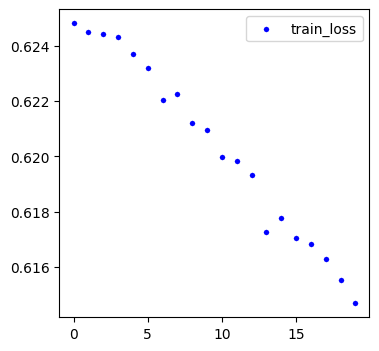

In [114]:
plt.figure(figsize=(4,4))
plt.scatter(y = hist,

            x = [_ for _ in range(len(hist))],
            alpha = 1, lw = 0.1, c = 'b', s = 14, label = 'train_loss')
plt.legend()
plt.show()

In [105]:
eval_model(model        = model,
           device       = device,
           data_loader  = train_loader,
           target_names = ['rec.motorcycles','rec.sport.baseball','sci.space'])

eval_model(model        = model,
           device       = device,
           data_loader  = test_loader,
           target_names = ['rec.motorcycles','rec.sport.baseball','sci.space'])

#torch.save(model.state_dict(),f = '/home/drew/Split-Learning/ScratchWork/model.tar')

                    precision    recall  f1-score   support

   rec.motorcycles       0.00      0.00      0.00       256
rec.sport.baseball       1.00      0.04      0.08       306
         sci.space       0.38      1.00      0.55       342

         micro avg       0.39      0.39      0.39       904
         macro avg       0.46      0.35      0.21       904
      weighted avg       0.48      0.39      0.24       904
       samples avg       0.39      0.39      0.39       904

                    precision    recall  f1-score   support

   rec.motorcycles       0.00      0.00      0.00        63
rec.sport.baseball       1.00      0.05      0.10        75
         sci.space       0.40      1.00      0.57        89

         micro avg       0.41      0.41      0.41       227
         macro avg       0.47      0.35      0.22       227
      weighted avg       0.49      0.41      0.26       227
       samples avg       0.41      0.41      0.41       227



---

## Visualizing the importance of words

In [106]:
sampling_dataset   = DataLoader(TensorDataset(X_train,Y_train) , batch_size = 10, shuffle = False)
X_sample, Y_sample = next(iter(sampling_dataset))
(X_sample.shape, Y_sample.shape)

(torch.Size([10, 93]), torch.Size([10, 3]))

In [107]:
# Obtain our trained model
model.eval()

Net(
  (embed): Embedding(13749, 200, padding_idx=0)
  (conv): Conv1d(200, 10, kernel_size=(3,), stride=(1,), padding=(1,))
  (U): Linear(in_features=10, out_features=3, bias=True)
  (final): Linear(in_features=10, out_features=3, bias=True)
  (embed_drop): Dropout(p=0.5, inplace=False)
)

## Extract a single instance and map out the attnmap for each label

In [108]:
x = model.embed (X_sample)
print("Embedding Shape: ",x.shape)
x = x.transpose (1, 2)
print("Transposing After Embedding",x.shape)
#apply convolution and nonlinearity (tanh)
x = F. tanh(model.conv(x).transpose(1,2))
print("Transpose after convultion",x.shape)
#apply attention
alpha = F.softmax(model.U.weight.matmul(x. transpose (1,2)) , dim=2)
print("Attn Map Shape: ",alpha.shape)
#document representations are weighted sums using the attention. Can compute all at once as a matmul
m = alpha.matmul(x)
print("Value multiplied by attn",m.shape)
#Final layer classification
y = model.final.weight.mul(m).sum(dim=2).add(model.final.bias)
print("Model Output shape: ",y.shape)

Embedding Shape:  torch.Size([10, 93, 200])
Transposing After Embedding torch.Size([10, 200, 93])
Transpose after convultion torch.Size([10, 93, 10])
Attn Map Shape:  torch.Size([10, 3, 93])
Value multiplied by attn torch.Size([10, 3, 10])
Model Output shape:  torch.Size([10, 3])


In [109]:
translate_dc = {v:k for k,v in dc.items()}

Predicted = sci.space


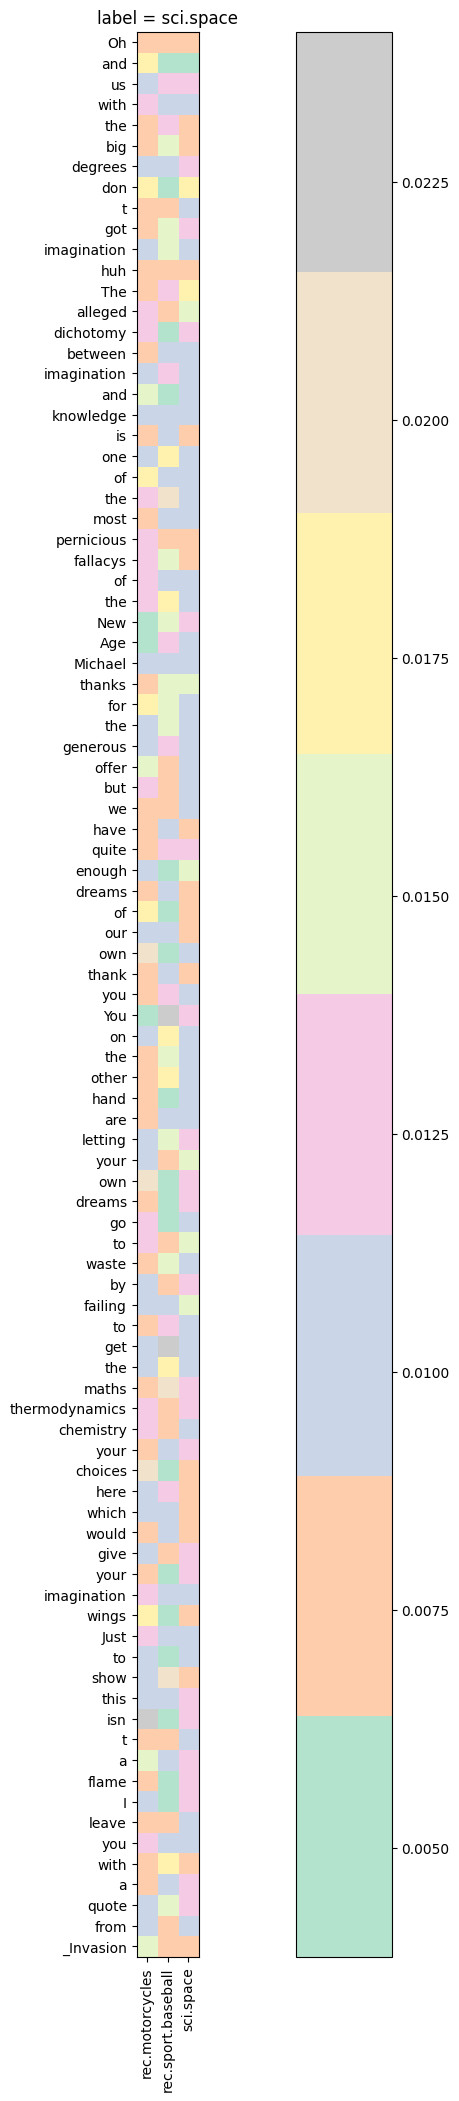

In [110]:
instance = 1
X_s = X_sample[instance].unsqueeze(dim = 0)
Y_s = Y_sample[instance].unsqueeze(dim = 0)
x = model.embed (X_s)
x = x.transpose (1, 2)
x = F. tanh(model.conv(x).transpose(1,2))
alpha = F.softmax(model.U.weight.matmul(x.transpose (1,2)) , dim=2)
m = alpha.matmul(x)
y = model.final.weight.mul(m).sum(dim=2).add(model.final.bias)

sample_words = np.array([translate_dc[int(w)] for w in X_s.flatten()])
# Model our attn map for our dataeu
target_names = ['rec.motorcycles','rec.sport.baseball','sci.space']

plt.figure(figsize=(25,25))
plt.title(label = f'label = {target_names[Y_s.argmax(dim = 1)]}' )
print(f'Predicted = {target_names[y.argmax(dim = 1)]}')
plt.imshow(alpha.squeeze(dim=0).T.detach().numpy(), cmap='Pastel2')

plt.yticks(ticks = [_ for _ in range(len(sample_words))], labels = sample_words,rotation = 0)
plt.xticks(ticks = [_ for _ in range(len(target_names))], labels = target_names,rotation = 90)

plt.colorbar()
plt.show()